In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from database_connection import load_data
df = load_data()

df.head()

,id,response_time,gender,return_plan,reason
0,1,2026-02-07 15:30:13,Male,Not Sure,Better quality of life abroad\r
1,2,2026-02-07 15:33:18,Male,Not Sure,Political situation\r
2,3,2026-02-07 15:34:42,Female,Not Sure,Better job opportunities abroad\r
3,4,2026-02-07 15:45:12,Female,No,Political situation\r
4,5,2026-02-07 15:45:38,Female,No,Family reasons\r


In [4]:
print(df.head())
print(df.columns)

   id       response_time  gender return_plan  \
0   1 2026-02-07 15:30:13    Male    Not Sure   
1   2 2026-02-07 15:33:18    Male    Not Sure   
2   3 2026-02-07 15:34:42  Female    Not Sure   
3   4 2026-02-07 15:45:12  Female          No   
4   5 2026-02-07 15:45:38  Female          No   

                              reason  
0    Better quality of life abroad\r  
1              Political situation\r  
2  Better job opportunities abroad\r  
3              Political situation\r  
4                   Family reasons\r  
Index(['id', 'response_time', 'gender', 'return_plan', 'reason'], dtype='str')


Optimization terminated successfully.
         Current function value: 0.523704
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          return_binary   No. Observations:                   82
Model:                          Logit   Df Residuals:                       80
Method:                           MLE   Df Model:                            1
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                0.004913
Time:                        14:48:17   Log-Likelihood:                -42.944
converged:                       True   LL-Null:                       -43.156
Covariance Type:            nonrobust   LLR p-value:                    0.5149
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.4469      0.393     -3.682      0.000      -2.217      -0.677
gender_Male     0.3483    

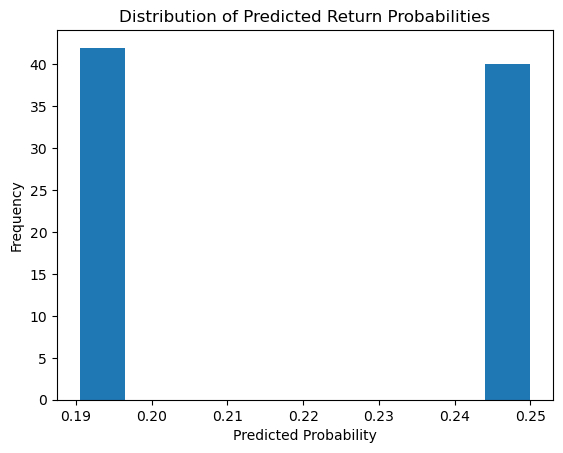

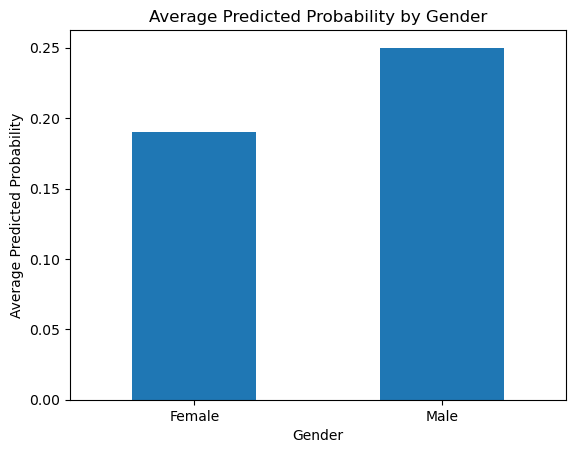


Confusion Matrix:
predicted_class   0
return_binary      
0                64
1                18


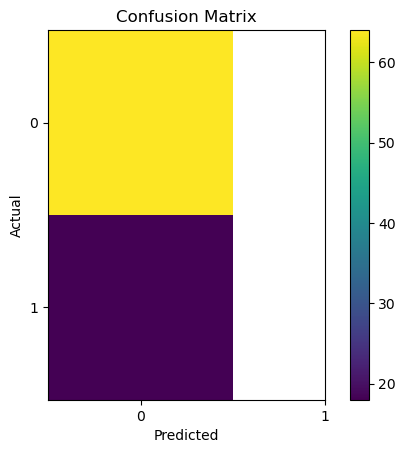

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

df['return_binary'] = df['return_plan'].apply(lambda x: 1 if x == "Yes" else 0)

X = pd.get_dummies(df[['gender']], drop_first=True)
X = X.astype(float)
X = sm.add_constant(X)

y = df['return_binary']

model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

df['predicted_prob'] = result.predict(X)

# Classification using 0.5 threshold
df['predicted_class'] = (df['predicted_prob'] >= 0.5).astype(int)

print("\nSample Prediction Probabilities:")
print(df[['gender', 'return_binary', 'predicted_prob', 'predicted_class']].head(10))
plt.figure()
plt.hist(df['predicted_prob'], bins=10)
plt.title("Distribution of Predicted Return Probabilities")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.show()

avg_prob = df.groupby('gender')['predicted_prob'].mean()

plt.figure()
avg_prob.plot(kind='bar')
plt.title("Average Predicted Probability by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Predicted Probability")
plt.xticks(rotation=0)
plt.show()

conf_matrix = pd.crosstab(df['return_binary'], df['predicted_class'])

print("\nConfusion Matrix:")
print(conf_matrix)

plt.figure()
plt.imshow(conf_matrix)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1])
plt.yticks([0,1])
plt.colorbar()
plt.show()